# Analysis Notebook for Nexus System v12 (v1.0.0)

Focus on v12 was the compilation of the full nexus system using 4 nexus segments and incorporating the Judge and Handler nodes. For segment specific analysis please refer to the Segment Handler Analysis notebook (found in the v10 folder). 

## Abstract:

### The issues:

Originally introduced in `SegmentHandlerAnalysis.ipynb`: Artificial Intelligence (AI) currently faces three major issues:
-	Size: AI models are incredibly large (up to a couple billion parameters sometimes). This can require massive datacenters with specific and expensive hardware, incurring major energy costs.
-	Transparency: Little is known about how AI makes its computations. It is frequently referred to as a black box.
-	Limited modularity: While Ais can be configured with different settings (ex. amount of hidden layers), it is difficult to isolate issues or integrate different models together.


### Intent:

The goal of this project is to find a way to help counter these issues securely. The “Nexus” system focuses on 3 areas:
-	Maintaining accuracy despite having less nodes
-	Improve traceability of computations
-	Maximize modularity, potentially integrating various types of AI’s together


### The Nexus:

Using a specialized 'Judge' node, I will route specific queries to different 'segments,' each with their own specialty in a specific type of data. The selected segments will then load their nodes and run the computation. The returns of these segments will be merged into a final prediction. Eventually, this process may be chained together with different specialist groups across a pipeline, but that exceeds the original intent. 
This approach will theoretically address the three issues previously discussed. 
-	Size: By dynamically loading specialist segments, I hope to lower the amount of time and memory it takes to run a computation. Why load 100 nodes if only 25 is needed? Additionally, I hope to be able to 'prune' unnecessary nodes. If a node is needless space, then I will get rid of it.
-	Transparency: I will create a custom segment type to allow better tracing of computations (both visually and statistically). This may potentially reveal more about how AI works.
-	Modularity: By having various specialist segments, the modularity of this framework will be guaranteed. Why not train segments separately in parallel? With this framework it would be possible to swap different segments as needed, allowing for various specializations to be configured as needed. 
Overall, we will be sacrificing the raw efficiency and simplicity of modern neural networks to have a potentially flexible, specialized, and interpretable system.


### Current Focus: The full system


The v12 iteration focuses on the development and evaluation of the full Nexus system. Building on the segment-level work in `SegmentHandlerAnalysis.ipynb`, this notebook integrates the `JudgeNode` routing layer and `HandlerNode` aggregation to assemble all segments into a complete multi-segment prediction pipeline, and benchmarks it against classical ML baselines on the same dataset and split.

### Observed Cons:

Currently I face these issues:

Training difficulty:
As previously observed, this will be a very difficult issue to address. Like before there are the segment specific issues:
- Sparse activation: It is difficult to update all the weights needed when only a subset of the nodes learn
- Overfitting: The narrower domain leads individual segments to have poor generalization skills
- Time complexity: The segment training involves both position and node weights. This makes time for training much more costly compared to a traditional model
- Node tracking: Tracking the nodes to determine which to prune is expensive
However, there are now some system specific training difficulties:


Risk:
Like previously observed:
- If the Judge node miscalculates or misroutes, the error could cascade and sharply impact performance
- If the Judge gets too complex then it could become a computationally heavy bottleneck 
- Data formatting: It would be necessary to have standardized inputs and outputs for each computation. For certain AI types, this could become costly to align
- Curse of Dimensionality: A feature of this framework is changing the number of dimensions used for computation as its graph based. Increasing the amount of dimensions can cause exponential growth in cost.


Implementation limitations:

Like before, careful practice can minimize the impacts of these cons, but compared to traditional model pipelines, these are much more difficult to counteract. Careful design is required when implementing this implementation.

Claude (Claude Sonnet 4.6) observed cons:

---

#### Training Cost

**Per-sample graph reconnection makes segment training O(epochs × samples × nodes²)**

After every training sample's position update in `_epoch()` (`SegmentHandler.py` lines 556–560), `connect_nearest_nodes()` is called for every processing node. That method sorts all processing and reviewer candidates by Euclidean distance — O(n log n) per node, O(n² log n) total per sample. For a 2D segment with `max_x=10` and `density=0.95`, a segment contains approximately 95 processing nodes. At 20 epochs × 20,000 samples × 4 segments, reconnection is called ~15 million times. This makes reconnection the dominant training cost at non-trivial dataset sizes, amplifying the time complexity concern already listed above.

*Note: the `freeze_connections` plateau flag partially mitigates this but only activates late in training when it has already been incurred for most epochs.*

---

#### Training Fragilities

**Non-deterministic JudgeNode clustering undermines reproducibility**

`generate_clusters()` initializes centroids via `random.sample()` with no fixed seed (`JudgeNode.py` line 55). The rest of the system explicitly sets `random.seed(42)` (`ProcessingNode.py` line 3), but this seeding is not inherited by the JudgeNode. Two training runs on identical data can therefore produce different cluster configurations, different cluster-to-segment assignments, and meaningfully different segment specialization profiles. This makes it difficult to diagnose performance regressions between runs, compare hyperparameter sweeps fairly, or reproduce a specific routing structure for deployment. The mismatch between the seeded segment code and the unseeded JudgeNode code also suggests this inconsistency is likely unintentional.

**Signal expiry silently reduces the effective training set**

Signal life is fixed at `max_x² × 0.8` steps at creation (`Signal.py` line 15 — 80 steps for `max_x=10`). A signal that expires before reaching any reviewer contributes zero gradient and zero loss for that forward pass. If every signal generated for a training sample expires, that sample is completely invisible to the weight and position update for that epoch. Early in training when routing is random and graph connectivity has not yet been refined, expiry rates can be substantial. The reported epoch loss averages only over samples that produced at least one reviewer prediction (the `count` guard in `_backprop`), so the loss metric during early epochs is not representative of the full dataset error — it is the error over only the fraction of samples that successfully produced predictions.

**Feature-order coupling between preprocessor and JudgeNode creates silent routing failures**

The JudgeNode records the column order of the training DataFrame at training time (`self.features = list(preprocessed_dataset.columns)`, `JudgeNode.py` line 320) and uses this order at inference to extract feature values in centroid-aligned order (`calculate_input_segment_relevance`, lines 117–124). This column order is determined by the sequence in which `tokenize_categorical()` discovers categorical values during the preprocessor warmup pass (`PreProcessingNode.py` lines 59–89). If any inference call arrives with a preprocessing vocabulary that differs from the one used during JudgeNode training — for instance, if the preprocessor is reinstantiated fresh, or if inference encounters a new category that shifts the column layout — the feature vector passed to the JudgeNode will have dimensions misaligned with the stored cluster centroids. Euclidean distances will then be computed against the wrong features, routing inputs to incorrect segments with no runtime error or warning.

---

#### System Design Constraints

**Plateau detection is irreversible and uses a scale-independent threshold**

Plateau is detected when the last 3 consecutive test error values vary by less than `PLATEAU_THRESHOLD = 3.0%` (`SegmentHandler.py` lines 944–952). Once plateau is detected, `freeze_connections=True` is passed to `_epoch()` and never reverted — there is no mechanism to re-enable topology updates if test error resumes improving in later epochs. This means a transient stall in test error permanently suppresses position learning for the remainder of training, even if the stall would have resolved naturally.

Additionally, the 3% threshold is an absolute percentage with no relationship to the scale or variance of the target variable. For exam scores (range ≈ 0–100), a 3% band corresponds to ≈ 3 score points — a reasonable plateau indicator. For targets with different magnitude or variance (house prices, physical sensor readings, financial returns), the same threshold may declare plateau too aggressively or too conservatively, requiring manual tuning per task.

**No cross-segment knowledge transfer during partitioned training**

In `partitioned` training mode, each segment receives only its assigned cluster rows (`SystemHandler.train()` lines 83–91) and learns its weights, feature relevance, and topology entirely from scratch on that subset. A predictive relationship that is universal across the input space — e.g., that `study_hours` strongly predicts `exam_score` regardless of cluster — must be independently rediscovered by every segment from its local partition. For a 4-segment system trained on 20,000 rows with an 80/20 split, each segment trains on roughly 4,000 samples. This exacerbates the overfitting risk already noted, since each segment faces a harder generalization problem than a single model trained on the full dataset would, with no mechanism to share learned representations across segments during or after training.

### Observed Pros:

Based on observation of the full system, the following advantages have been identified:

**Modularity:**
The segment-based design provides genuine modularity. Each segment is an independent unit that can be trained, saved (`.nexseg`), loaded, or swapped without affecting other parts of the system. It is therefore practical to replace underperforming segments, train specialist segments in parallel, or introduce new segments for new data domains without retraining the entire system.

**Specialization via JudgeNode Partitioning:**
When trained in `partitioned` mode, each segment receives only the rows assigned to its cluster group. This causes each segment's processing nodes and feature-relevance weights to adapt toward a specific region of the input space — analogous to Mixture of Experts (MoE), but realized through a graph-based topology rather than gating networks.

**Computational Efficiency at Inference:**
Only a subset of segments (`selection_percentage`, default 50%) is activated per inference call. The system therefore scales sub-linearly: doubling the number of segments does not double inference cost because only the most relevant segments are queried. Node pruning (Step 4 of training) further reduces per-segment cost by removing processing nodes that were never activated during training.

**Traceability:**
Signal `path_contributions` are recorded during every forward pass. Every processing node on a signal's path logs its weighted contribution, distance-based scaling, and per-feature details. The splitter's `signal_weights` capture learned feature-relevance scores. Together these allow the full computation path to be audited — substantially more interpretable than inspecting raw activations in a standard neural network.

**Topology Adaptability:**
Processing node positions are learned parameters updated by gradient descent during training, with connections rebuilt after each epoch based on the new geometry. The graph topology itself therefore adapts to the training data, allowing segments to converge on a spatial arrangement that reflects the structure of their assigned partition.

**Robust Aggregation:**
The HandlerNode's BMA mode weights each segment by its JudgeNode relevance score divided by inter-reviewer variance. Segments that are both geographically relevant to the input and internally consistent (low variance across their reviewer predictions) contribute more to the final answer. This degrades gracefully if a segment produces a noisy or irrelevant prediction.

### Potential Applications:

I have observed these potential applications:

Claude (Claude Sonnet 4.6) observed applications:

The JudgeNode's input-space partitioning, per-segment specialization, signal path traceability, `.nexseg` portability, and BMA aggregation each map directly to real-world requirements in several broad domains. The applications below identify the specific property that justifies each use.

---

### Cybersecurity

The combination of JudgeNode routing and signal `path_contributions` traceability makes the architecture well-suited to security workloads where both accuracy and auditability matter.

- **Network Intrusion Detection:** Traffic feature vectors (packet size, flow duration, protocol distribution, port entropy) cluster naturally by attack category. Each segment can specialize in a distinct threat profile — e.g., volumetric DDoS, lateral movement, data exfiltration — while the JudgeNode routes incoming flows to the relevant specialist(s). The `path_contributions` record provides a per-alert explanation of which features drove the prediction, which is operationally important for analyst triage. *Justification: JudgeNode partitioned routing + signal traceability. Aligns with the simulated attack demo stated in Next Plans.*

- **Alert Triage and False Positive Reduction:** In high-volume SOC environments, alert fatigue is a primary problem. A system where segments specialize in known-benign behavioral clusters can be used as a first-pass filter, routing alerts to the segment whose cluster profile best matches the observed behavior and surfacing only those where the prediction is uncertain (high inter-reviewer variance in BMA). *Justification: BMA variance weighting naturally expresses prediction confidence; high-variance segments signal uncertain cases for human review.*

- **Behavioral Anomaly Detection (Insider Threat):** User activity logs (login times, resource access patterns, data volumes) cluster by normal behavioral archetype. Segments trained on these clusters detect deviations from the archetype assigned to each user's cluster at JudgeNode routing time. Anomalies appear as inputs with low relevance to all clusters — the JudgeNode assigns low scores across all segments, and the resulting predictions will be inconsistent (high variance), which BMA naturally down-weights while still surfacing the case. *Justification: low cross-cluster relevance scores surface as a detectable signal in the JudgeNode output.*

---

### Healthcare & Life Sciences

Interpretability requirements and patient subgroup heterogeneity make this domain a natural fit for the segment-specialization model.

- **Multi-Condition Diagnostic Decision Support:** Patient records cluster by symptom profile and medical history. Segments trained on these clusters develop feature weights tuned to the diagnostic patterns of each cluster. The `path_contributions` trail allows a clinician to inspect which symptoms most influenced a prediction for a specific patient — a requirement in regulated clinical contexts that post-hoc methods like SHAP cannot guarantee on a per-prediction basis. *Justification: per-prediction path traceability + JudgeNode specialization.*

- **Drug Response and Treatment Outcome Prediction:** Patients can be clustered by pharmacogenomic or comorbidity profiles. A segment specializing in each patient cluster can predict drug efficacy or adverse event risk with weights tuned to that subpopulation. The `.nexseg` portability allows hospital systems to train segments on their own patient data privately and share only the weight files for aggregation. *Justification: `.nexseg` federated portability + segment specialization per patient subtype.*

- **Patient Risk Stratification:** ICU or readmission risk models often fail because a single model applies generic weights to a heterogeneous population. JudgeNode partitioning groups patients by clinical similarity; each segment develops risk weights appropriate for its subgroup. The HandlerNode BMA then combines segment outputs weighted by how closely the current patient matches each segment's cluster, providing a graceful interpolation for patients who lie at cluster boundaries. *Justification: BMA boundary interpolation + subgroup specialization.*

---

### Financial Services

Regulatory explainability requirements and the natural clustering structure of financial behavior make this a high-value domain.

- **Credit Risk Assessment:** Loan applicants cluster by financial behavior profile (debt utilization, payment history, income stability). Each segment learns credit risk weights calibrated to its cluster. The `path_contributions` record provides a feature-level explanation for every credit decision, directly satisfying model explainability requirements under frameworks such as SR 11-7 (Federal Reserve model risk guidance) and GDPR Article 22 (automated decision-making). *Justification: per-prediction traceability satisfies regulatory explainability obligations that post-hoc approximation methods may not.*

- **Transaction Fraud Detection:** Payment transactions cluster by behavioral type (recurring bills, point-of-sale, cross-border transfers, large one-off purchases). Each segment specializes in the fraud patterns relevant to its transaction cluster. A new transaction is routed to its best-matching segment(s), preventing the dilution of fraud signal that occurs when rare fraud patterns are averaged into a single monolithic model's weights. *Justification: JudgeNode routing concentrates rare-pattern training signal within the segment most exposed to that pattern.*

- **Portfolio and Market Risk Modeling:** Asset classes cluster by risk factor exposure (rate sensitivity, credit spread, volatility). Segments can specialize in each asset cluster's risk dynamics. The modular `.nexseg` structure makes it practical to retrain a single segment when one asset class's dynamics shift (e.g., after a regime change) without retraining the full system. *Justification: independent `.nexseg` retrainability without full-system disruption.*

---

### Industrial Systems & IoT

Constrained deployment environments and multi-modal sensor data create natural alignment with the architecture's modularity and portability.

- **Predictive Maintenance:** Machine sensor readings (vibration spectrum, temperature, current draw) cluster by operating condition and wear state. Segments trained on these clusters detect degradation signatures specific to each operating regime. Because each segment is a self-contained `.nexseg` file, individual segments can be deployed on edge devices with limited memory rather than loading the full system, directly addressing the size concern stated in the project intent. *Justification: `.nexseg` portability enables edge deployment; segment activation at inference means only the relevant specialist is loaded.*

- **Multi-Modal Sensor Fusion:** Different sensor types measure fundamentally different physical phenomena (acoustic emission, thermal imaging, vibration). Segments can be assigned to modality clusters, with the HandlerNode combining their outputs into a unified health score. This is directly analogous to the heterogeneous ensemble use case enabled by the `comparisons/` wrappers, where different model types (CNN for image, MLP for numerical) can occupy different segments. *Justification: HandlerNode aggregates heterogeneous segment types without requiring compatible internal representations.*

- **Manufacturing Quality Control:** Product defect profiles cluster by defect type (surface, dimensional, compositional). A JudgeNode trained on defect feature distributions routes inspection readings to the segment specialist for the most likely defect type. Low confidence outputs (high BMA variance) flag items for human inspection rather than automatic pass/fail. *Justification: BMA variance as a natural confidence signal for human escalation.*

---

### Research & Interpretable AI

The architecture's computation traceability makes it a practical tool for studying how models derive predictions.

- **Explainable AI Research:** The `path_contributions` dict records, per signal, the exact weighted contribution of every feature at every node along the signal's path. This is a richer internal explanation than attention weights or SHAP values because it reflects the actual computation graph rather than a post-hoc approximation. Researchers studying feature attribution, path dependence, or routing dynamics in graph-based models can use the Nexus architecture as a controlled experimental platform. *Justification: `path_contributions` is a first-class audit trail, not a post-hoc approximation.*

- **Adaptive Educational Systems:** Student performance data clusters by learning profile (study method, schedule, course type). Segments trained on these clusters can predict outcomes for students matching each profile. The splitter's `signal_weights` show which features (e.g., `study_hours` vs. `sleep_quality`) are most predictive for each cluster, providing an interpretable basis for personalized intervention recommendations. *Justification: per-segment feature relevance weights expose which inputs matter most for each student archetype.*

---

### Multi-Party & Distributed Learning

The `.nexseg` serialization format enables a federated architecture where only trained weight files — not raw data — cross organizational boundaries.

- **Federated Learning Across Organizations:** Each party trains one or more segments on their private dataset and shares only the resulting `.nexseg` files. A central coordinator re-runs the JudgeNode on a shared representative sample (or a synthetic proxy) to establish routing, then combines the segments into a full system. No raw training data is transmitted. *Justification: `.nexseg` files contain only weights, positions, and connection structure — no training data.*

- **Incremental Domain Expansion:** When a new data domain appears post-deployment, a new segment is initialized, trained on the new domain's data, and registered with the JudgeNode without disturbing existing segments. The JudgeNode clustering is extended to include the new domain's cluster(s). This is a lower-cost expansion than retraining a monolithic model, and the existing segments' specializations are preserved. *Justification: `SystemHandler.initializeAllSegments()` and `JudgeNode.assign_clusters_to_segments()` can be called incrementally; existing `.nexseg` files are not modified.*

## The various nodes/components:

Referenced previously in the v10 analysis, here is a recap:


#### Segment Nodes:
- Splitter Node: This node generates the initial signals and distributes that information to its nearest p% of processing nodes. It also calculates a feature relevance score for each feature to help give emphasis of certain features which may be relevant to the given dataset.

- Processing Node: These nodes are designed to be the main computational node in this neural net. Each processing node has a queue to store signals as they come in. These nodes use the current input as a feature, other feature weights, distance-based scaling and clamping to update a given prediction. They update a given prediction instead of generating a new one. To forward signals they save their signature in the signals visited nodes, and for each connected node calculate a weight for each node before randomly selecting one to forward to. This places emphasis on reviewer nodes and nodes further from the origin than others. In the case of a dead end, the signal will reset the list of the last 3 visited nodes. This list is a hard buffer preventing the visit of the past 3 visited nodes, but in the case of a dead end this list is reset allowing for back tracking of a given signal.

- Reviewer Node: The reviewer node is strictly mathematical without learning. It waits until each signal is received before reviewing the signals with inverse variance weighting so that signals with less variance (a more direct path) have higher weight. With this, it uses weighted sums which becomes the final prediction for that node.

#### Universal nodes/components:
- Signal: The signal is the key component in the processing. It is simply a class that saves the current prediction, variance, position, etc. 

- Preprocessing node: This node is implemented in segment handler as it is required for all preprocessing needed. When computing for a specific input, it will tokenize the categorical data and normalize the lists, tuples, or series. When handling full databases, it drops the removable columns, takes care of missing values, and then treats each row as an input to generate the database. Scalars themselves are not normalized.

#### Now-implemented System Nodes:
- Judge node: This node is designed to generate clusters from the data. This could allow for segments to specialize in a manner akin to Mixture of Experts models. Inputs will be distributed to needed segments accordingly.
- Handler node: Like a segment Reviewer node except the handler is designed to handle all reviewer node returns. However, this node uses a count of predictions, not weights.




## The Key Settings

For segment-specific settings (max_x, connection percentage, density, etc.), see `SegmentHandlerAnalysis.ipynb` in this folder.

These are the new settings:
- Judge Iters: The number of iterations the judge node will go through when finding the optimal number of clusters (default: 20).
- Judge Min Clusters: The minimum number of clusters the judge node will test (default: 4)
- Judge Max clusters: The maximium number of clusters the judge node will test (default: 20).
- Selection Percentage: The percentage of segments that will be activated for an inference (default: .5).
- Training Mode: determines how the data will be partitioned. If set to partitioned, then the judge node routing will be used. If set to full, then each segment will receive the full dataset.
- Aggregation Mode: This determines how aggregation is comuted. If ba is selected, then aggregation will follow a BMA computation using relevance and variance weighting. Simple mean will aggregate with equal weighting average. Relevance weighted focuses on just normalized relevance scores.
- Seg Colors: Colors to represent each segment on a combined graph.

For a detailed walkthrough of the segment training and inference procedure, see `SegmentHandlerAnalysis.ipynb` in this folder.

# Explanation of the Judge Node
*Explained by Claude Sonnet 4.6*

The **JudgeNode** (`Components/JudgeNode.py`) is the routing intelligence of the Nexus system. Its role is to learn a partition of the input feature space during training and, at inference time, direct each query to only the most relevant segments.

---

### Training Phase

**Step 1 — K-means Clustering**

The JudgeNode receives the preprocessed dataset with the target column removed. Clustering over input features only is essential: including the target would cause clusters to reflect output value ranges (e.g., grouping all low-scoring students together), making segments degenerate specialists in output ranges rather than input structure.

`generate_clusters()` runs K-means across a sweep of cluster counts (from `judge_min_clusters` to at most `judge_max_clusters`, one increment per iteration). For each candidate count, up to 100 iterations of standard K-means are run:
- Each data point is assigned to the nearest centroid by Euclidean distance.
- Centroids are recomputed as the mean of their assigned points.
- Convergence is declared when no centroid moves more than `1e-6`.
- Empty clusters are reseeded from a random data point so the count never collapses.

**Step 2 — Cluster Quality Scoring**

Each clustering configuration is scored by three complementary metrics computed per cluster:

| Metric | Intuition |
|--------|-----------|
| **Geometric Uniqueness** `G` | `nearest_centroid_distance / (mean_radius + ε)` — rewards clusters that are well-separated from neighbours relative to their own spread. High score = compact, isolated cluster. |
| **Behavioral Diversity** `B` | Mean absolute difference in relevance scores `(1 / (1 + distance))` between this cluster and every other cluster, averaged over all data points. High score = membership in this cluster is highly discriminative. |
| **Information Gain** `I` | `(cluster_size / dataset_size) × mean_relevance_to_centroid` — rewards clusters that are both large and cohesive. High score = dense, representative cluster. |

The composite `ClusterScore = w1·G + w2·B + w3·I` (all weights default to 1.0).

A **balance bonus** is applied at the configuration level:
```
combined_score = raw_avg_score × (1 + 1 / (1 + CV))
```
where `CV` is the coefficient of variation of cluster sizes. This penalises configurations where one cluster holds nearly all points and others are nearly empty.

**Step 3 — Optimal Configuration Selection**

All scored configurations are sorted by combined score. The configuration with the highest score is re-generated to finalize cluster assignments, and the cluster metrics are recalculated one final time.

**Step 4 — Cluster-to-Segment Assignment**

`assign_clusters_to_segments()` uses a greedy algorithm (largest clusters first) to assign each cluster to a segment:

```
cost = distance_cost + balance_weight × excess_ratio
```
- `distance_cost` = Euclidean distance between the cluster centroid and the segment's running mean centroid (normalized by max inter-centroid distance). Nearby clusters prefer the same segment.
- `excess_ratio` = how much this segment already exceeds the ideal samples-per-segment load. Penalises overloading any one segment.

After assignment the segment's running centroid is updated as a weighted average. The result is a balanced assignment where segments are both spatially coherent and load-balanced.

---

### Inference Phase

Given a preprocessed input (target column stripped; features extracted in training column order so distances align with centroid dimensions):

1. For each cluster, compute `relevance = 1 / (1 + euclidean_distance(input, centroid))`. Relevance is 1.0 when the input lies exactly at the centroid and approaches 0.0 as distance grows.
2. Per segment, take the **maximum** relevance across all clusters assigned to it — the single best-matching cluster determines how relevant a segment is.
3. Sort segments by relevance descending; select the top `ceil(n_segments × selection_percentage)` (minimum 1).
4. Return the selected `(segment_id, relevance_score)` pairs to `SystemHandler`. The relevance score is forwarded to the HandlerNode so that segments closer to the input carry more weight in the final aggregation.

# Explanation of the Handler Node
*Explained by Claude Sonnet 4.6*

The **HandlerNode** (`Components/HandlerNode.py`) is the output aggregation layer of the Nexus system. It collects predictions from every activated segment and merges them into a single final prediction.

---

### Role and Position in the Pipeline

Where the `ReviewerNode` within each segment merges signal predictions *inside* one segment using inverse-variance weighting, the HandlerNode operates at the system level — merging predictions *across* segments. It is the last computational node in the inference pipeline before the final value is returned to the caller.

---

### Receiving Reports

Each time `SystemHandler.runInfer()` dispatches to a selected segment, that segment's `segmentInfer()` returns one report per `ReviewerNode` that produced a valid prediction. For each report, `HandlerNode.receive_report()` buffers three values:

- `segment_id` — which segment produced this prediction
- `segment_relevance` — the JudgeNode score for this segment (proximity of the input to the segment's cluster space)
- `prediction` — the floating-point value returned by that reviewer

All reports accumulate until `process_reports()` is called.

---

### Aggregation Modes

`process_reports()` groups all buffered predictions by `segment_id` and computes a per-segment mean. It then assigns a weight to each segment according to `aggregation_mode`:

**`bma` (Bayesian Model Averaging) — Default**

```
weight = segment_relevance / max(inter_reviewer_variance, ε)
```

Two factors jointly determine trust:
1. *Relevance* — segments whose cluster centroid is closer to the input are trusted more.
2. *Inverse variance* — segments whose internal reviewers agree with each other (low variance across their predictions for this input) are trusted more. A segment that is geographically relevant but whose reviewers produce wildly different values is down-weighted.

All BMA weights are then normalized relative to their maximum so no single segment can dominate simply because its variance happens to be near zero.

**`relevance_weighted`**

```
weight = segment_relevance
```

Uses only the JudgeNode proximity score, ignoring internal segment consistency. Equivalent to BMA without the variance term.

**`simple_mean`**

```
weight = 1.0  (equal for all segments)
```

Unweighted average. Useful as a baseline or before the JudgeNode has been trained.

---

### Final Prediction and State Reset

```
final_prediction = Σ (segment_mean × weight) / Σ weight
```

If the total weight is zero (e.g., all relevance scores are zero), the denominator falls back to equal weighting to avoid division by zero.

After returning the prediction, the HandlerNode clears its `reports` buffers completely so it is ready for the next inference call without retaining state between calls.

# Explanation of the Full Inference Procedure
*Explained by Claude Sonnet 4.6*

The following describes the complete path an input takes from raw data to a final system-level prediction. All stages are orchestrated by `SystemHandler.runInfer()`.

---

## Stage 1: Input Preprocessing
**Code:** `PreProcessingNode.process_data()`

The raw input (a Python dict, typically one row from the CSV) passes through four steps:

1. **Drop removable columns** — columns listed in `removable_columns` (e.g., `student_id`) are deleted from the dict.
2. **Handle missing values** — keys with `None` values are removed.
3. **Tokenize categorical features** — string-valued columns are one-hot encoded using the vocabulary learned at training time. Each observed category `col_value` becomes a binary key `col_value = 1`; all other known categories for that column are set to `0`. Unseen values extend the vocabulary on the fly.
4. **Pass through numerics** — scalar `int` and `float` values are returned as-is. Min-max normalization applies only to list/Series inputs (which arise during dataset-level preprocessing, not single-row inference).

Output: a flat `{feature_name: float}` dictionary.

---

## Stage 2: JudgeNode Routing
**Code:** `JudgeNode.calculate_input_segment_relevance()` → `find_relevant_segments()`

The target column key is stripped from the preprocessed dict. Feature values are then extracted in the exact column order recorded during JudgeNode training so that Euclidean distances are computed in the same coordinate space as the stored cluster centroids.

For each cluster in `segment_weights['clusters']`:
```
relevance = 1 / (1 + euclidean_distance(input_vector, cluster_centroid))
```
Relevance is 1.0 when the input lies exactly at the centroid and approaches 0.0 as distance grows.

Per-segment relevance is the **maximum** score across all clusters assigned to that segment. Segments are sorted descending by this score; the top `ceil(n_segments × selection_percentage)` are selected (minimum 1). The result is a list of `(segment_id, relevance_score)` pairs passed back to `SystemHandler`.

If the JudgeNode has not been trained, all segments are activated with equal relevance of 1.0.

---

## Stage 3: Per-Segment Processing
**Code:** `SegmentHandler.segmentInfer()` — run once per selected segment

Each segment runs a full forward pass independently.

### 3a. Signal Generation (SplitterNode)

The SplitterNode computes a `feature_relevance` dict from its learned `signal_weights` — per-feature scalars trained by gradient descent to emphasize features predictive for this segment's data partition. It then creates one `Signal` object per connected processing node (the nearest `connection_percentage` fraction of all nodes). Each signal starts with:

- `prediction = 0.0`
- `variance = 0.0`
- `input` = preprocessed feature dict
- `signal_life = max_x² × 0.8` — a fixed budget of steps before expiry

Signals are dispatched to the splitter's connected nodes, launching them into the graph.

### 3b. Graph Traversal Loop (ProcessingNodes)

The segment iterates up to 500 times. On each iteration every `ProcessingNode` holding a signal runs `process_signal()`:

```
weighted_sum  = prediction × w_input_pred
              + Σ (feature_value × feature_weight × feature_relevance)

scaled_delta  = clamp(weighted_sum / (1 + distance_to_origin),  ±DELTA_CLIP)

new_prediction = clamp(prediction + scaled_delta,  ±PRED_CLIP)
variance       += |scaled_delta|
```

Key design choices:
- **Cumulative prediction:** the signal's prediction is updated incrementally at every node, not replaced. Each node refines the running estimate.
- **Distance scaling:** dividing by `(1 + distance_to_origin)` means nodes near the splitter produce larger deltas (high influence, early in the path) while distant nodes apply finer adjustments.
- **Variance tracking:** `variance` accumulates the total absolute change along the signal's path. High variance signals traveled a noisy, winding route; low variance signals took a direct path to the reviewer.

After processing, the node routes the signal to one of its connected candidates. Routing is probabilistic, weighted by:
- **Outward alignment** — candidates in the direction away from the origin are preferred.
- **Distance to origin** — more distant candidates score higher.
- **Reviewer bonus (×3.0)** — ReviewerNodes are strongly preferred as routing targets.

The three most recently visited nodes are excluded to suppress tight loops. If all candidates are excluded (dead end), the exclusion list is cleared to allow backtracking.

### 3c. Reviewer Collection and Aggregation (ReviewerNode)

When a signal reaches a ReviewerNode it is marked `collected = True` and appended to the reviewer's signal list. After the traversal loop ends, each reviewer runs `review_signals()` using **inverse-variance weighting**:

```
weight_i  = 1 / max(signal.variance, ε)
prediction = Σ (signal.prediction × weight_i) / Σ weight_i
```

Signals that reached the reviewer quickly and consistently (low accumulated variance) carry more weight than those that wandered through many nodes. Each reviewer that received at least one active signal produces one `{id, prediction, reviewer_position}` report.

---

## Stage 4: HandlerNode Aggregation
**Code:** `HandlerNode.process_reports()`

All reviewer reports from all activated segments are buffered in the HandlerNode. Reports are grouped by `segment_id`; each group's mean prediction is computed. A weight is assigned to each segment according to the chosen `aggregation_mode` (BMA by default — see HandlerNode explanation), and the final weighted sum is divided by the total weight:

```
final_prediction = Σ (segment_mean × weight) / Σ weight
```

The HandlerNode then clears its state and returns the final prediction.

---

## Summary Flow

```
Raw Input Dict
      │
      ▼
 PreProcessingNode       ← tokenize categoricals, drop IDs, pass numerics
      │
      ▼
  JudgeNode              ← score each cluster, select top-K segments by relevance
      │
      ├── Segment 0 ─────────────────────────────────────────────────┐
      │     SplitterNode → signals → ProcessingNode graph → Reviewers│
      ├── Segment 2 ─────────────────────────────────────────────────┤
      │     SplitterNode → signals → ProcessingNode graph → Reviewers│
      └── ...                                                         │
                                                                      ▼
                                                             HandlerNode
                                                    (BMA / relevance / mean)
                                                                      │
                                                                      ▼
                                                          Final Prediction (float)
```

## DEMO:

This demo will focus on the full system implentation with training and inference. Similar to the segment demo, it will feature pre-training, training, and post training procedures.

### The training data:
Like before, I am using a dataset from Kaggle called Exam Score Prediction. It is a csv with the following information:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset

data = pd.read_csv('Exam_Score_Prediction.csv')

print("\nFirst 5 rows of the dataset:")
data.head()



First 5 rows of the dataset:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [2]:

print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


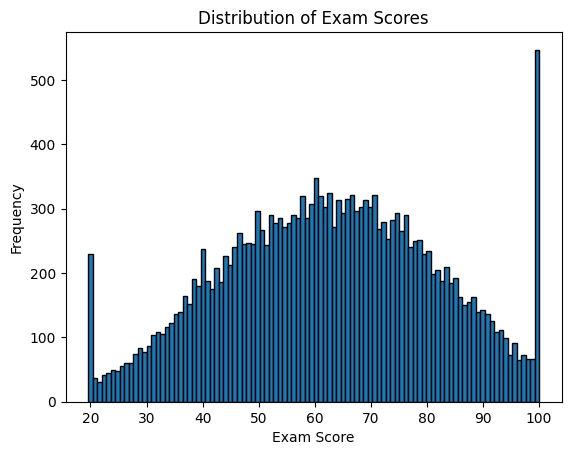

In [3]:
plt.hist(data['exam_score'], bins=100, edgecolor='black')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam Scores')
plt.show()

In [4]:
import sys, os, time, math
sys.path.insert(0, '.')

import Components.NotebookLogger as NotebookLoggerModule
from SystemHandler import SystemHandler
from Components.PreProcessingNode import PreProcesingNode

# ── Configuration ─────────────────────────────────────────────────────────
TARGET_COL           = "exam_score"
EPOCH_COUNT          = 20
JUDGE_ITERS          = 20
JUDGE_MIN_CLUSTERS   = 4
JUDGE_MAX_CLUSTERS   = 20
SELECTION_PERCENTAGE = 0.5
MAX_X                = 10
DIMENSIONS           = 2
CONN_PCT             = 0.1
DENSITY              = 0.8
TRAINING_MODE        = "partitioned"   # "partitioned" | "full"
AGGREGATION_MODE     = "bma"           # "bma" | "simple_mean" | "relevance_weighted"
IGNORED_COLS         = ['student_id']

# Shuffle once so pre/post results are over a random sample order
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Logger ─────────────────────────────────────────────────────────────────
logger = NotebookLoggerModule.NotebookLogger(
    f"system_analysis_notebook_{int(time.time())}.log",
    log_level=2, console_level = 4,
)
print("=" * 60)
print("  Nexus System Handler — v12 Demo")
print("=" * 60)

# ── Evaluation sample (row 0 of the shuffled dataset, withheld from infer) ─
sample_raw = data.iloc[0].to_dict()
actual     = float(sample_raw.get(TARGET_COL))
logger.log(f"Evaluation sample  |  actual {TARGET_COL}: {actual}", 4, True)

# ── Shared preprocessor warmup ─────────────────────────────────────────────
print("\n--- Warming Up Preprocessor ---")
preprocessor = PreProcesingNode(
    Logger=logger, logger_classification=2,
    removable_columns=IGNORED_COLS,
)
preprocessor.process_dataset(data.copy())
logger.log("Preprocessor vocabulary built.", 4, True)

# ── Build and initialise the system ───────────────────────────────────────
print("\n--- Initialising System ---")
system = SystemHandler(
    maxX=MAX_X,
    target=TARGET_COL,
    logger=logger,
    connection_percentage=CONN_PCT,
    density=DENSITY,
    dimensions=DIMENSIONS,
    classification=4,
    removable_columns=IGNORED_COLS,
)
system.initializeAllSegments(Loud=True)

print(f"\nSystem Configuration:")
print(f"  Segment Count    : {len(system.segments)}")
print(f"  Segment IDs      : {[s.segment_id for s in system.segments]}")
print(f"  Max X            : {MAX_X}")
print(f"  Dimensions       : {DIMENSIONS}")
print(f"  Connection %     : {CONN_PCT}")
print(f"  Density          : {DENSITY}")
print(f"  Training Mode    : {TRAINING_MODE}")
print(f"  Aggregation Mode : {AGGREGATION_MODE}")
print(f"  Selection %      : {SELECTION_PERCENTAGE}")
print(f"  Target Column    : {TARGET_COL}")
print(f"  Dataset Rows     : {len(data)}")


  Nexus System Handler — v12 Demo

--- Warming Up Preprocessor ---


Pre-processing dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

[INFO]: Evaluation sample  |  actual exam_score: 31.1

--- Initialising System ---


Segment 0 Creating Nodes:   0%|          | 0/63 [00:00<?, ?it/s]

Segment 0 Connecting Nodes:   0%|          | 0/63 [00:00<?, ?it/s]

...

Segment 2 Creating Nodes:   0%|          | 0/64 [00:00<?, ?it/s]

Segment 2 Connecting Nodes:   0%|          | 0/64 [00:00<?, ?it/s]

Segment 3 Creating Nodes:   0%|          | 0/64 [00:00<?, ?it/s]

Segment 3 Connecting Nodes:   0%|          | 0/64 [00:00<?, ?it/s]


System Configuration:
  Segment Count    : 4
  Segment IDs      : [0, 1, 2, 3]
  Max X            : 10
  Dimensions       : 2
  Connection %     : 0.1
  Density          : 0.8
  Training Mode    : partitioned
  Aggregation Mode : bma
  Selection %      : 0.5
  Target Column    : exam_score
  Dataset Rows     : 20000


### Pre training inference:


In [5]:
# Pre-training inference: JudgeNode has not been trained yet, so all segments
# are activated at equal relevance (1.0 each).  This establishes a baseline
# that will be compared against the post-training result.
print("\n--- Pre-Training Inference ---")

pre_prediction = system.runInfer(
    sample_raw.copy(),
    loud=False,
    aggregation_mode=AGGREGATION_MODE,
    selection_percentage=SELECTION_PERCENTAGE,
)

pre_err = (
    abs(pre_prediction - actual) / abs(actual) * 100.0
    if pre_prediction is not None and actual
    else float('nan')
)

_abs_pre = abs(pre_prediction - actual) if pre_prediction is not None and actual is not None else None

print(f"\n{'Stage':<15} {'Prediction':>12} {'Actual':>12} {'Abs Error':>12} {'Error %':>10}")
print("-" * 64)
print(f"{'Pre-Training':<15} "
      f"{f'{pre_prediction:.4f}' if pre_prediction is not None else '—':>12} "
      f"{actual:>12.4f} "
      f"{f'{_abs_pre:.4f}' if _abs_pre is not None else '—':>12} "
      f"{f'{pre_err:.2f}%' if not math.isnan(pre_err) else '—':>10}")
logger.log(f"Segments activated: {system.getNumberSegmentsUsed()}", 4, True)



--- Pre-Training Inference ---
[INFO]: [Main]: Initialized 4 segments


Segment 0 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 2 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 3 Inference:   0%|          | 0/3 [00:00<?, ?it/s]


Stage             Prediction       Actual    Abs Error    Error %
----------------------------------------------------------------
Pre-Training         85.6198      31.1000      54.5198    175.30%
[INFO]: Segments activated: 4


### Training:
Below is where I demonstrate the training of the model with 20 epochs.

In [ ]:
print("\n--- Training ---")

if TRAINING_MODE == "full":
    system.train_full(data, epoch_count=EPOCH_COUNT, loud=True)
else:
    system.train(
        data,
        epoch_count=EPOCH_COUNT,
        judge_iterations=JUDGE_ITERS,
        loud=True,
        judge_min_clusters=JUDGE_MIN_CLUSTERS,
        judge_max_clusters=JUDGE_MAX_CLUSTERS,
    )

logger.log("Training complete.", 4, True)

# ── Per-segment best-epoch summary ────────────────────────────────────────
seg_metrics = [s.best_epoch_metrics for s in system.segments
               if s.best_epoch_metrics is not None]
if seg_metrics:
    print(f"\nPer-Segment Best-Epoch Test Metrics")
    print(f"  {'Seg':>4} {'Best Ep':>8} {'Train Rows':>11} {'MAE':>10} {'RMSE':>10} "
          f"{'R²':>8} {'MAPE':>10} {'Dir Acc':>9} {'F1':>8} {'Acc@10%':>9}")
    print("  " + "-" * 95)
    _nan = lambda v: f"{v:.4f}" if not math.isnan(v) else "—"
    for m in seg_metrics:
        print(f"  {m['segment_id']:>4} {m['best_epoch']:>8} {m['n_train']:>11} "
              f"{m['mae']:>10.4f} {m['rmse']:>10.4f} {_nan(m['r2']):>8} "
              f"{m['mape']:>9.2f}% {m['dir_acc']:>8.1f}% {_nan(m['f1']):>8} "
              f"{m['acc_10']:>8.1f}%")



--- Training ---


Pre-processing dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

[INFO]: [Main]: Training JudgeNode — clustering full dataset...


### Post Test Inference and Summary

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
from tqdm.auto import tqdm
matplotlib.use("Agg")

# Suppress per-segment progress bars during inference
logger.disable_progress = True

# ── Post-training single-sample inference ─────────────────────────────────
print("\n--- Post-Training Inference ---")

post_prediction = system.runInfer(
    sample_raw.copy(),
    loud=True,
    aggregation_mode=AGGREGATION_MODE,
    selection_percentage=SELECTION_PERCENTAGE,
)

post_err = (
    abs(post_prediction - actual) / abs(actual) * 100.0
    if post_prediction is not None and actual
    else float('nan')
)
improvement = (
    (pre_err - post_err)
    if not (math.isnan(pre_err) or math.isnan(post_err))
    else float('nan')
)

_abs_post = abs(post_prediction - actual) if post_prediction is not None and actual is not None else None

print(f"\n{'Stage':<15} {'Prediction':>12} {'Actual':>12} {'Abs Error':>12} {'Error %':>10}")
print("-" * 64)
print(f"{'Pre-Training':<15} "
      f"{f'{pre_prediction:.4f}' if pre_prediction is not None else '—':>12} "
      f"{actual:>12.4f} "
      f"{f'{_abs_pre:.4f}' if _abs_pre is not None else '—':>12} "
      f"{f'{pre_err:.2f}%' if not math.isnan(pre_err) else '—':>10}")
print(f"{'Post-Training':<15} "
      f"{f'{post_prediction:.4f}' if post_prediction is not None else '—':>12} "
      f"{actual:>12.4f} "
      f"{f'{_abs_post:.4f}' if _abs_post is not None else '—':>12} "
      f"{f'{post_err:.2f}%' if not math.isnan(post_err) else '—':>10}")
if not math.isnan(improvement):
    direction = "▼" if improvement > 0 else "▲"
    print(f"\n  Improvement: {direction} {abs(improvement):.2f}%")

logger.log(f"Segments activated (post): {system.getNumberSegmentsUsed()}", 4, True)

# ── Full test-set evaluation (last 20% of dataset) ────────────────────────
print("\n--- System Test Evaluation ---")

_split_idx   = int(len(data) * 0.8)
_test_ds     = data.iloc[_split_idx:].reset_index(drop=True)
_sys_preds, _sys_actuals = [], []

for _, _row in tqdm(_test_ds.iterrows(), total=len(_test_ds), desc="Evaluating test rows"):
    _row_dict = _row.to_dict()
    _actual_v = _row_dict.get(TARGET_COL)
    if _actual_v is None:
        continue
    _pred = system.runInfer(_row_dict, loud=False,
                            aggregation_mode=AGGREGATION_MODE,
                            selection_percentage=SELECTION_PERCENTAGE)
    if _pred is not None:
        _sys_preds.append(float(_pred))
        _sys_actuals.append(float(_actual_v))

logger.disable_progress = False  # restore for subsequent cells

_sys_n = len(_sys_preds)
if _sys_n > 0:
    _mae    = sum(abs(p - a) for p, a in zip(_sys_preds, _sys_actuals)) / _sys_n
    _rmse   = math.sqrt(sum((p - a) ** 2 for p, a in zip(_sys_preds, _sys_actuals)) / _sys_n)
    _mean_a = sum(_sys_actuals) / _sys_n
    _ss_tot = sum((a - _mean_a) ** 2 for a in _sys_actuals)
    _ss_res = sum((p - a) ** 2 for p, a in zip(_sys_preds, _sys_actuals))
    _r2     = 1.0 - _ss_res / _ss_tot if _ss_tot > 0 else float('nan')
    _mape   = sum(abs(p - a) / abs(a) * 100.0
                  for p, a in zip(_sys_preds, _sys_actuals) if a != 0) / _sys_n

    def _sys_within(pct):
        return sum(1 for p, a in zip(_sys_preds, _sys_actuals)
                   if a != 0 and abs(p - a) / abs(a) <= pct) / _sys_n * 100.0
    _acc5, _acc10, _acc20 = _sys_within(0.05), _sys_within(0.10), _sys_within(0.20)

    _sorted_a = sorted(_sys_actuals)
    _median_a = _sorted_a[_sys_n // 2]
    _ap = [1 if a >= _median_a else 0 for a in _sys_actuals]
    _pp = [1 if p >= _median_a else 0 for p in _sys_preds]
    _tp = sum(1 for a, p in zip(_ap, _pp) if a == 1 and p == 1)
    _fp = sum(1 for a, p in zip(_ap, _pp) if a == 0 and p == 1)
    _fn = sum(1 for a, p in zip(_ap, _pp) if a == 1 and p == 0)
    _tn = sum(1 for a, p in zip(_ap, _pp) if a == 0 and p == 0)
    _prec = _tp / (_tp + _fp) if (_tp + _fp) > 0 else float('nan')
    _rec  = _tp / (_tp + _fn) if (_tp + _fn) > 0 else float('nan')
    _f1   = (2 * _prec * _rec / (_prec + _rec)
             if not (math.isnan(_prec) or math.isnan(_rec)) and (_prec + _rec) > 0
             else float('nan'))
    _dir_acc = (_tp + _tn) / _sys_n * 100.0

    _fv = lambda v, d=4: f"{v:.{d}f}" if not math.isnan(v) else "—"

    print(f"\nSystem Test Evaluation  (n={_sys_n}, last 20% of dataset)")
    print(f"  {'MAE':<25} {_fv(_mae)}")
    print(f"  {'RMSE':<25} {_fv(_rmse)}")
    print(f"  {'R²':<25} {_fv(_r2)}")
    print(f"  {'MAPE':<25} {f'{_mape:.2f}%' if not math.isnan(_mape) else '—'}")
    print(f"  {'Within  5% accuracy':<25} {f'{_acc5:.1f}%' if not math.isnan(_acc5) else '—'}")
    print(f"  {'Within 10% accuracy':<25} {f'{_acc10:.1f}%' if not math.isnan(_acc10) else '—'}")
    print(f"  {'Within 20% accuracy':<25} {f'{_acc20:.1f}%' if not math.isnan(_acc20) else '—'}")
    print(f"  {'Direction accuracy':<25} {f'{_dir_acc:.1f}%' if not math.isnan(_dir_acc) else '—'}")
    print(f"  {'Precision (median)':<25} {_fv(_prec)}")
    print(f"  {'Recall    (median)':<25} {_fv(_rec)}")
    print(f"  {'F1        (median)':<25} {_fv(_f1)}")
    print(f"  {'TP / FP / FN / TN':<25} {_tp} / {_fp} / {_fn} / {_tn}")

    # ── Predicted vs actual scatter ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(_sys_actuals, _sys_preds, alpha=0.25, s=6, color='steelblue', label='Predictions')
    _lo = min(min(_sys_actuals), min(_sys_preds))
    _hi = max(max(_sys_actuals), max(_sys_preds))
    ax.plot([_lo, _hi], [_lo, _hi], 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel("Actual exam_score")
    ax.set_ylabel("Predicted exam_score")
    ax.set_title(f"Predicted vs Actual  (n={_sys_n})\nR²={_r2:.4f}  MAPE={_mape:.2f}%  MAE={_mae:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig("system_pred_vs_actual.png", dpi=120)
    plt.show()
    logger.log("Scatter plot saved → system_pred_vs_actual.png", 4, True)
else:
    logger.log("No predictions produced on test split.", 3, True)

# ── JudgeNode cluster report ──────────────────────────────────────────────
clusters = system.JudgeNode.segment_weights.get('clusters', [])
if clusters:
    print(f"\nJudgeNode Clusters  ({len(clusters)} clusters → {len(system.segments)} segments)")
    print(f"  {'Cluster':>7} {'Segment':>7} {'Size':>7} {'Geo Uniq':>10} {'Behav Div':>10} {'Info Gain':>10} {'Score':>10}")
    print("  " + "-" * 62)
    for i, c in enumerate(clusters):
        m = c.get('metrics', {})
        print(f"  {i:>7} {str(c.get('segment_id', '—')):>7} {len(c['points']):>7} "
              f"{m.get('GeometricUniqueness', 0):>10.4f} "
              f"{m.get('BehavioralDiversity', 0):>10.4f} "
              f"{m.get('InformationGain', 0):>10.4f} "
              f"{m.get('ClusterScore', 0):>10.4f}")
    _avg = lambda k: sum(c.get('metrics', {}).get(k, 0) for c in clusters) / len(clusters)
    print("  " + "-" * 62)
    print(f"  {'Average':>7} {'—':>7} {'—':>7} "
          f"{_avg('GeometricUniqueness'):>10.4f} "
          f"{_avg('BehavioralDiversity'):>10.4f} "
          f"{_avg('InformationGain'):>10.4f} "
          f"{_avg('ClusterScore'):>10.4f}")

# ── Combined nexus graph (post-training) ──────────────────────────────────
SEG_COLORS = ["steelblue", "tomato", "mediumseagreen", "darkorchid",
              "darkorange", "hotpink", "teal", "saddlebrown"]

fig2, ax2 = plt.subplots(figsize=(10, 10))
ax2.axhline(0, color='black', linewidth=0.6, alpha=0.4)
ax2.axvline(0, color='black', linewidth=0.6, alpha=0.4)
for seg in system.segments:
    sc   = SEG_COLORS[seg.segment_id % len(SEG_COLORS)]
    comp = seg.segmentComponents
    if comp is None:
        continue
    splitter   = comp['splitter']
    reviewers  = comp['reviewer']
    processors = comp['processing_nodes']
    for node in processors:
        ax2.scatter(node.position[0], node.position[1], color=sc, s=12, alpha=0.6, zorder=2)
        for tgt in node.connected_nodes:
            ax2.plot([node.position[0], tgt.position[0]],
                     [node.position[1], tgt.position[1]],
                     color=sc, linewidth=0.4, alpha=0.2, zorder=1)
    for tgt in splitter.connected_nodes:
        ax2.plot([splitter.position[0], tgt.position[0]],
                 [splitter.position[1], tgt.position[1]],
                 color=sc, linewidth=0.5, alpha=0.35, zorder=1, linestyle='--')
    ax2.scatter(splitter.position[0], splitter.position[1],
                color=sc, s=120, marker='D', zorder=4,
                label=f"Seg {seg.segment_id} splitter")
    for rev in reviewers:
        ax2.scatter(rev.position[0], rev.position[1],
                    color=sc, s=150, marker='*', zorder=4)
ax2.set_title("Nexus — Post-Training Structure", fontsize=14, fontweight='bold')
ax2.set_xlabel("X"); ax2.set_ylabel("Y")
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=7, framealpha=0.8)
fig2.tight_layout()
fig2.savefig("nexus_posttrain.png", dpi=150)
plt.show()
logger.log("Post-training nexus graph saved → nexus_posttrain.png", 4, True)



--- Post-Training Inference ---
[INFO]: Training complete.

Stage             Prediction       Actual    Abs Error    Error %
----------------------------------------------------------------
Pre-Training         85.6198      31.1000      54.5198    175.30%
Post-Training        37.7576      31.1000       6.6576     21.41%

  Improvement: ▼ 153.90%

--- System Test Evaluation ---


Evaluating test rows:   0%|          | 0/4000 [00:00<?, ?it/s]


System Test Evaluation  (n=4000, last 20% of dataset)
  MAE                       10.4031
  RMSE                      12.9245
  R²                        0.5441
  MAPE                      18.43%
  Within  5% accuracy       17.7%
  Within 10% accuracy       34.3%
  Within 20% accuracy       66.0%
  Direction accuracy        80.2%
  Precision (median)        0.8246
  Recall    (median)        0.7687
  F1        (median)        0.7957
  TP / FP / FN / TN         1542 / 328 / 464 / 1666


C:\Users\georg\AppData\Local\Temp\ipykernel_34384\3638013529.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



JudgeNode Clusters  (4 clusters → 4 segments)
  Cluster Segment    Size   Geo Uniq  Behav Div  Info Gain      Score
  --------------------------------------------------------------
        0       0    5069     2.5412     0.0648     0.0200     2.6259
        1       1    5029     2.5835     0.0720     0.0172     2.6727
        2       3    4941     2.5344     0.0714     0.0168     2.6226
        3       2    4962     2.5354     0.0646     0.0195     2.6196
  --------------------------------------------------------------
  Average       —       —     2.5486     0.0682     0.0184     2.6352


C:\Users\georg\AppData\Local\Temp\ipykernel_34384\3638013529.py:194: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Comparing to other models

In [ ]:
# Since the demo would be too much for my poor laptop i delegated
# this task to a cloud compute server. This is the code ran.

"""
import comparisons.ComparisonManager as CompMgr
import Components.NotebookLogger as LoggerModule
import Components.RichConsole as RichConsole
import time
import pandas as pd
logger = RichConsole.RichLogger(log_level=4, console_level=4, filename=f"segment_analysis_notebook_{int(time.time())}.log")

manager = CompMgr.ComparisonManager(logger=logger)
dataset = pd.read_csv("Exam_Score_Prediction.csv")
target  = "exam_score"


JUDGE_ITERS          = 20
JUDGE_MIN_CLUSTERS   = 4
JUDGE_MAX_CLUSTERS   = 20
SELECTION_PERCENTAGE = 0.5
TRAINING_MODE        = "partitioned"

manager.run_all(
    dataset                     = dataset,
    target                      = target,
    epoch_count                 = 20,

    # ── Classical baselines ────────────────────────────────────────────────
    run_linear                  = True,
    run_knn                     = True,
    run_rf                      = True,
    run_xgb                     = True,
    run_mlp                     = True,
    run_cnn                     = True,

    # ── Single-segment Nexus (isolated segment baseline) ──────────────────
    # Runs the segment handler alone (no JudgeNode/HandlerNode) at two
    # graph sizes so the multi-segment system can be compared against a
    # single-segment configuration of similar node count.
    run_segment                 = True,
    segment_max_x               = [5, 10, 15, 20, 25, 30, 35],

    # ── Full multi-segment Nexus system ───────────────────────────────────
    # Runs SystemHandler with the same settings used in this notebook demo.
    # All three aggregation modes are tested to show their relative effect.
    run_system                  = True,
    system_max_x                = [10, 15, 20, 25, 30],
    system_dimensions           = 2,
    system_training_mode        = TRAINING_MODE,
    system_judge_iterations     = JUDGE_ITERS,
    system_judge_min_clusters   = JUDGE_MIN_CLUSTERS,
    system_judge_max_clusters   = JUDGE_MAX_CLUSTERS,
    system_aggregation_modes    = ["bma", "simple_mean", "relevance_weighted"],
    system_selection_percentage = SELECTION_PERCENTAGE,
)


"""


'\nimport comparisons.ComparisonManager as CompMgr\nimport Components.NotebookLogger as LoggerModule\nimport Components.RichConsole as RichConsole\nimport time\nimport pandas as pd\nlogger = RichConsole.RichLogger(log_level=4, console_level=4, filename=f"segment_analysis_notebook_{int(time.time())}.log")\n\nmanager = CompMgr.ComparisonManager(logger=logger)\ndataset = pd.read_csv("Exam_Score_Prediction.csv")\ntarget  = "exam_score"\n\n\nJUDGE_ITERS          = 20\nJUDGE_MIN_CLUSTERS   = 4\nJUDGE_MAX_CLUSTERS   = 20\nSELECTION_PERCENTAGE = 0.5\nTRAINING_MODE        = "partitioned"\n\nmanager.run_all(\n    dataset                     = dataset,\n    target                      = target,\n    epoch_count                 = 20,\n\n    # ── Classical baselines ────────────────────────────────────────────────\n    run_linear                  = True,\n    run_knn                     = True,\n    run_rf                      = True,\n    run_xgb                     = True,\n    run_mlp           

In [2]:
import pandas as pd
results = pd.read_csv("comparison_results.csv")
print(f"\nComparison results loaded from 'comparison_results.csv'  ({len(results)} rows):")
results.head(30)


Comparison results loaded from 'comparison_results.csv'  (37 rows):


,timestamp,run_id,model_name,model_config,target,n_features,n_train,n_test,epoch_count,train_time_sec,...,recall,f1,tp,fp,fn,tn,best_epoch,best_test_error_pct,related_train_error_pct,notes
0,2026-07-01 22:14:37,20260629_165443,CNN,"filters=8,kernel=3,conv_layers=1,dense=[64, 32...",exam_score,31,16000,4000,20,967.3959,...,0.000000,NaN,0,0,2007,1993,NaN,inf,NaN,pure-python backprop
1,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=5,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,217.5443,...,0.000000,NaN,0,0,2007,1993,4.0,32.1854,28.1996,"max_x=5,dim=2"
2,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=10,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,1696.6480,...,0.059791,0.109689,120,61,1887,1932,3.0,30.4673,22.8950,"max_x=10,dim=2"
3,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=15,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,5571.3490,...,0.662681,0.758699,1330,169,677,1824,19.0,17.3029,5.7202,"max_x=15,dim=2"
4,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=20,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,12478.6998,...,0.779273,0.812679,1564,278,443,1715,20.0,16.2138,8.9037,"max_x=20,dim=2"
5,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=25,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,25202.7862,...,0.782760,0.817378,1571,266,436,1727,18.0,15.8580,14.4505,"max_x=25,dim=2"
6,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=30,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,53773.6991,...,0.829098,0.835132,1664,314,343,1679,20.0,15.5815,9.2473,"max_x=30,dim=2"
7,2026-07-01 22:14:37,20260629_165443,SegmentHandler,"max_x=35,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,94230.5437,...,0.712506,0.786362,1430,200,577,1793,20.0,17.1307,16.9208,"max_x=35,dim=2"
8,2026-07-05 02:40:46,20260702_000126,CNN,"filters=8,kernel=3,conv_layers=1,dense=[64, 32...",exam_score,31,16000,4000,20,967.3959,...,0.000000,NaN,0,0,2007,1993,NaN,inf,NaN,pure-python backprop
9,2026-07-05 02:40:46,20260702_000126,SegmentHandler,"max_x=5,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,217.5443,...,0.000000,NaN,0,0,2007,1993,4.0,32.1854,28.1996,"max_x=5,dim=2"


### Model comparison — best F1 per configuration

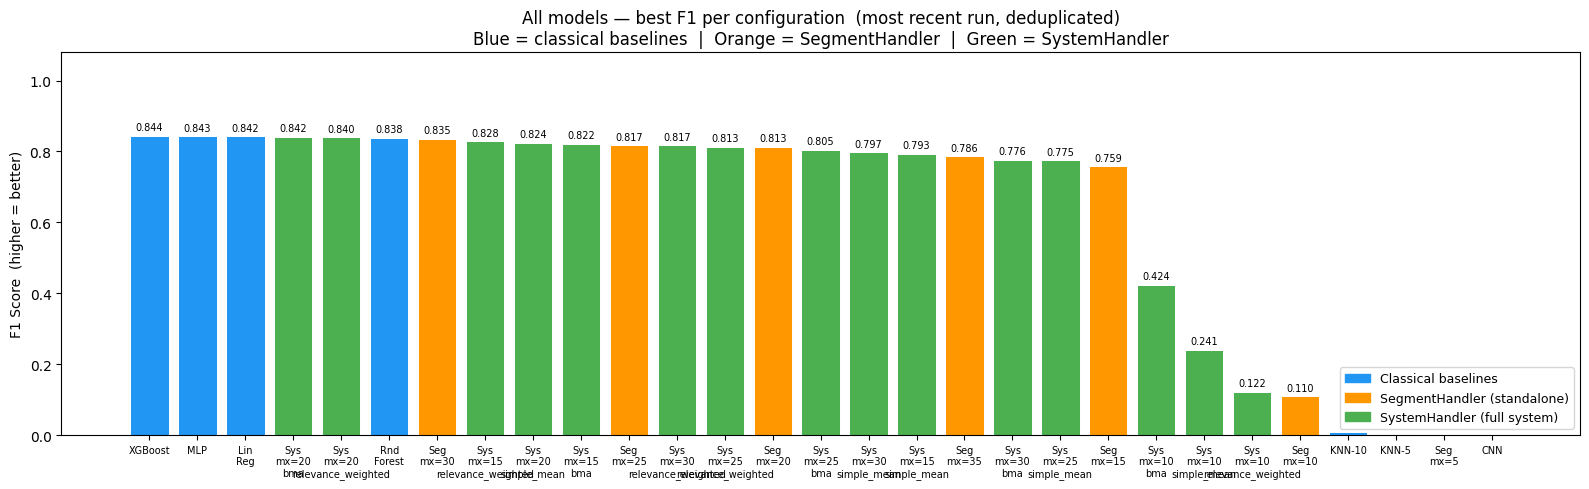

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import re

df = results.copy()
df["f1"] = pd.to_numeric(df["f1"], errors="coerce")

# Use the most recent run only (highest timestamp per model/config pair)
df = df.sort_values("timestamp", ascending=False).drop_duplicates(
    subset=["model_name", "model_config"]
)

def short_label(row):
    model = row["model_name"]
    cfg   = str(row.get("model_config") or "")

    if model == "SegmentHandler":
        m = re.search(r"max_x=(\d+)", cfg)
        return f"Seg\nmx={m.group(1)}" if m else "Seg"
    if model == "SystemHandler":
        mx = re.search(r"max_x=(\d+)", cfg)
        agg = re.search(r"agg=(\w+)", cfg)
        mx_s  = f"mx={mx.group(1)}" if mx else ""
        agg_s = agg.group(1) if agg else ""
        return f"Sys\n{mx_s}\n{agg_s}"

    abbrev = {
        "LinearRegression": "Lin\nReg",
        "RandomForest":     "Rnd\nForest",
        "XGBoost":          "XGBoost",
        "MLP":              "MLP",
        "CNN":              "CNN",
    }
    if model in abbrev:
        return abbrev[model]
    m = re.search(r"k=(\d+)", model)
    if m:
        return f"KNN-{m.group(1)}"
    return model

df["label"] = df.apply(short_label, axis=1)
df = df.sort_values("f1", ascending=False, na_position="last").reset_index(drop=True)

# Color by model family
family_map = {
    "LinearRegression": "#2196F3",
    "RandomForest":     "#2196F3",
    "XGBoost":          "#2196F3",
    "MLP":              "#2196F3",
    "KNN(k=5)":         "#2196F3",
    "KNN(k=10)":        "#2196F3",
    "CNN":              "#2196F3",
    "SegmentHandler":   "#FF9800",
    "SystemHandler":    "#4CAF50",
}
default_color = "#9E9E9E"
colors = [family_map.get(m, default_color) for m in df["model_name"]]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(df["label"], df["f1"].fillna(0).clip(lower=0),
              color=colors, edgecolor="white", linewidth=0.7)

ax.set_ylim(0, 1.08)
ax.set_ylabel("F1 Score  (higher = better)")
ax.set_title("All models — best F1 per configuration  (most recent run, deduplicated)\n"
             "Blue = classical baselines  |  Orange = SegmentHandler  |  Green = SystemHandler")
ax.axhline(0, color="black", linewidth=0.4)

for bar, val in zip(bars, df["f1"]):
    if pd.notna(val) and val > 0.01:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

legend_handles = [
    mpatches.Patch(color="#2196F3", label="Classical baselines"),
    mpatches.Patch(color="#FF9800", label="SegmentHandler (standalone)"),
    mpatches.Patch(color="#4CAF50", label="SystemHandler (full system)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()


### SystemHandler — aggregation mode comparison across max_x sizes

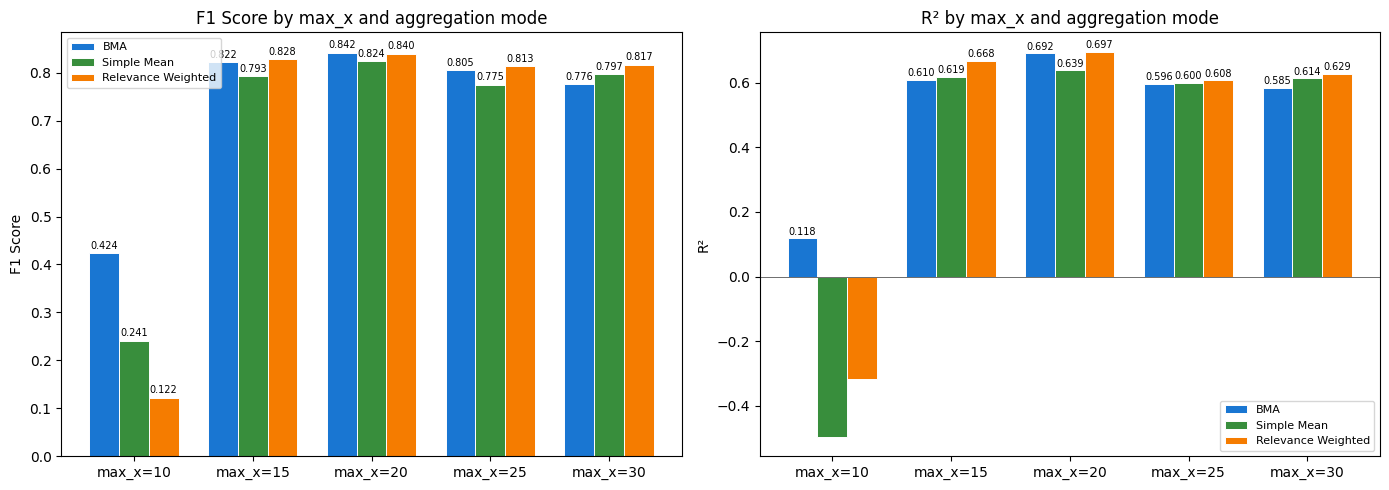

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

df = results.copy()
df["f1"]  = pd.to_numeric(df["f1"],  errors="coerce")
df["r2"]  = pd.to_numeric(df["r2"],  errors="coerce")
df["mae"] = pd.to_numeric(df["mae"], errors="coerce")

sys_df = df[df["model_name"] == "SystemHandler"].copy()
if sys_df.empty:
    print("No SystemHandler rows found in results.")
else:
    # Extract max_x and agg from model_config
    sys_df["max_x"] = sys_df["model_config"].str.extract(r"max_x=(\d+)").astype(int)
    sys_df["agg"]   = sys_df["model_config"].str.extract(r"agg=(\w+)")

    # Use most recent run per (max_x, agg)
    sys_df = (sys_df.sort_values("timestamp", ascending=False)
                    .drop_duplicates(subset=["max_x", "agg"])
                    .sort_values("max_x"))

    agg_modes = ["bma", "simple_mean", "relevance_weighted"]
    agg_labels = {"bma": "BMA", "simple_mean": "Simple Mean", "relevance_weighted": "Relevance Weighted"}
    agg_colors = {"bma": "#1976D2", "simple_mean": "#388E3C", "relevance_weighted": "#F57C00"}

    max_x_vals = sorted(sys_df["max_x"].unique())
    x = np.arange(len(max_x_vals))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, ylabel, title in [
        (axes[0], "f1",  "F1 Score",  "F1 Score by max_x and aggregation mode"),
        (axes[1], "r2",  "R²",        "R² by max_x and aggregation mode"),
    ]:
        for i, agg in enumerate(agg_modes):
            subset = sys_df[sys_df["agg"] == agg].set_index("max_x")
            vals = [subset.loc[mx, metric] if mx in subset.index else np.nan
                    for mx in max_x_vals]
            offset = (i - 1) * width
            bars = ax.bar(x + offset, vals, width,
                          label=agg_labels[agg], color=agg_colors[agg],
                          edgecolor="white", linewidth=0.7)
            for bar, v in zip(bars, vals):
                if pd.notna(v) and v > 0.05:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.005,
                            f"{v:.3f}", ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels([f"max_x={mx}" for mx in max_x_vals])
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.axhline(0, color="black", linewidth=0.4)

    plt.tight_layout()
    plt.show()


# Claude analysis of results

*Generated by Claude Code*

This analysis covers the most recent comparison run (`run_id=20260702_000126`), which is the most complete run to date: it includes all classical baselines, standalone `SegmentHandler` at seven graph sizes (`max_x` 5–35), and `SystemHandler` (4 segments, partitioned training) at five sizes (`max_x` 10–30) under all three aggregation modes. All models share the same 80/20 split (16,000 train / 4,000 test) on `Exam_Score_Prediction.csv`.

---

### Headline numbers

| Model | MAE | R² | F1 | direction_acc% | train_time |
|---|---|---|---|---|---|
| LinearRegression | **7.78** | **0.741** | 0.842 | **84.1%** | 0.04s |
| XGBoost | 8.16 | 0.710 | **0.844** | 83.8% | 0.6s |
| MLP | 8.12 | 0.713 | 0.843 | 83.7% | 2.6s |
| RandomForest | 8.28 | 0.707 | 0.838 | 83.5% | 3.0s |
| KNN (k=5 or k=10) | 15.8–16.8 | −0.14 to −0.01 | ≈0 | ≈50% | <0.1s — **FAILED** |
| CNN | — | — | 0.000 | 49.8% | 967s — **FAILED** |
| SegmentHandler max_x=30 *(standalone, best)* | 8.39 | 0.697 | 0.835 | 83.6% | ~15 hrs |
| **SystemHandler max_x=20, relevance_weighted *(best)*** | **8.42** | **0.697** | **0.840** | 83.4% | ~3.7 hrs |

Notable: the best SystemHandler configuration (F1=0.840) is within 0.002 of LinearRegression (F1=0.842) — effectively tied on F1. It does not yet beat any classical baseline on MAE or R², but the gap to LinearRegression (0.64 MAE, 0.044 R²) is the smallest it has been.

**Two models failed completely:** both KNN variants (R²≈0, direction_acc≈50%) and CNN (no predictions). KNN's failure is likely caused by the lack of per-feature normalization prior to the distance calculation — the preprocessed features mix vastly different scales, and KNN is highly sensitive to this. CNN continues to fail due to pure-Python backpropagation instability.

---

### Does the Judge/Handler system actually help?

Comparing standalone `SegmentHandler` against `SystemHandler` at the same `max_x` isolates the effect of partitioning and aggregation from graph size:

| max_x | Standalone R² (best) | System R² (best agg.) | System benefit |
|---|---|---|---|
| 10 | −0.468 (failed) | 0.118 (bma) | **+0.586 — rescues a failed model** |
| 15 | 0.582 | 0.668 (rel_weighted) | +0.086 |
| 20 | 0.660 | 0.697 (rel_weighted) | +0.037 |
| 25 | 0.673 | 0.608 (rel_weighted) | **−0.065 — system is worse** |

At `max_x=10`, partitioning turns a failing segment into a functional system — the most striking demonstration of the core architectural idea. The benefit shrinks as `max_x` grows and each segment becomes individually capable. At `max_x=25`, the system actually *hurts*: the 4-segment system divides 16,000 training rows across 4 segments (~4,000 each), while the standalone segment sees all 16,000. With a max_x=25 graph (over 400 nodes per segment), each segment is undertrained on its partition, whereas the single segment has enough data to make use of that capacity. This crossover is a practical constraint: for graphs this size, the standalone segment is a better choice unless there is a strong reason to expect specialist segments to outperform a generalist.

---

### Aggregation mode: pattern changed from previous analysis

The previous analysis found `simple_mean` to be the best aggregation at `max_x=15` and `max_x=20`. The new run reverses this:

| max_x | bma (MAE / R²) | simple_mean (MAE / R²) | relevance_weighted (MAE / R²) |
|---|---|---|---|
| 10 | **14.60 / 0.118** | 19.56 / −0.497 | 17.82 / −0.318 |
| 15 | 9.63 / 0.610 | 9.57 / 0.619 | **8.84 / 0.668** |
| 20 | 8.48 / 0.692 | 9.19 / 0.639 | **8.42 / 0.697** |
| 25 | 9.71 / 0.596 | 9.74 / 0.600 | **9.58 / 0.608** |
| 30 | 9.93 / 0.585 | 9.52 / 0.614 | **9.31 / 0.629** |

`relevance_weighted` is consistently the strongest aggregation mode at `max_x≥15`. `bma` wins only at `max_x=10`, where individual segments are too noisy for simple weighting to be reliable. The shift from the previous run's `simple_mean` dominance is likely due to JudgeNode non-determinism — different cluster assignments between runs change which samples each segment specialises on, which in turn changes how well the relevance scores from the JudgeNode align with actual segment quality. The aggregation mode comparison is not a clean ablation until JudgeNode seeding is fixed (see data quality caveat below).

---

### SystemHandler max_x sweet spot: 20, not 15 or 25

The data now spans `max_x=10` through `max_x=30` for the full system:

| max_x | Best R² | Best MAE | Best agg. | Train time (total) |
|---|---|---|---|---|
| 10 | 0.118 | 14.60 | bma | ~2.6 hrs |
| 15 | 0.668 | 8.84 | rel_weighted | ~4.7 hrs |
| **20** | **0.697** | **8.42** | **rel_weighted** | **~10.8 hrs** |
| 25 | 0.608 | 9.58 | rel_weighted | ~18.8 hrs |
| 30 | 0.629 | 9.31 | rel_weighted | ~35.9 hrs |

`max_x=20` is the clear sweet spot. Past `max_x=20`, accuracy degrades (the crossover with standalone described above) while training time continues to grow super-linearly with `max_x`. The node count per segment scales as `density × max_x²` in 2D, so `max_x=30` has 2.25× the nodes of `max_x=20` but measurably worse results.

---

### Inference cost scaling

At `selection_percentage=0.5`, 2 of 4 segments are active per inference. The expectation is ~2× a single segment plus routing overhead. The reality:

| max_x | Standalone inference (4,000 rows) | System inference (best agg.) | Multiplier |
|---|---|---|---|
| 10 | 5.8s | 40.7s | **7× over standalone** |
| 15 | 21.1s | 61.3s | **2.9× over standalone** |
| 20 | 49.5s | 103.5s | **2.1× over standalone** |
| 25 | 96.2s | 186.3s | **1.9× over standalone** |
| 30 | 195.9s | 333.3s | **1.7× over standalone** |

The multiplier drops sharply as `max_x` grows, consistent with a large fixed overhead from JudgeNode routing and HandlerNode aggregation that becomes proportionally smaller as each segment's own inference time grows. At `max_x=25` the overhead is approaching the theoretical 2× minimum, suggesting the fixed costs are dominated by segment compute at that scale. The `max_x=10` multiplier of 7× with only `bma` producing a positive R² explains why small-graph system deployments are impractical despite the accuracy benefit from partitioning.

---

### Data quality caveat: train time variation within max_x

Training time varies substantially across aggregation-mode rows at the same `max_x` (e.g., at `max_x=20`: bma=12,003s, simple_mean=13,268s, relevance_weighted=13,418s — an 11.8% spread). Since the aggregation mode is an inference-time choice that does not affect training, these rows represent independently retrained systems, not one system evaluated three ways. The JudgeNode's unseeded `random.sample()` centroid initialisation means each run can produce different cluster assignments, different segment specialisations, and correspondingly different training times and accuracy. Aggregation-mode comparisons are therefore directionally informative but not a clean ablation. A rigorous comparison requires training the system once per `max_x` with a fixed JudgeNode seed and varying the aggregation function only at inference time.

---

### Summary

The full Nexus system, at its best configuration (`max_x=20`, `relevance_weighted`), reaches R²=0.697 and F1=0.840 — within 0.044 R² of LinearRegression and essentially tied on F1. This is the closest the architecture has come to the classical baseline frontier. The core architectural idea — partitioning with JudgeNode and aggregating specialist predictions — is clearly validated at small `max_x` (rescuing a failing segment at max_x=10) and continues to add modest value at `max_x=15–20`. Past `max_x=20`, the standalone segment outperforms the system because training-data-per-segment becomes the binding constraint rather than graph capacity. The next most impactful fixes, in order of likely return: (1) seed the JudgeNode to make runs reproducible and ablations clean; (2) address the fixed inference overhead at small `max_x`; (3) investigate KNN normalisation failure as a clue about preprocessor behaviour that may also affect the Nexus.

## Next Plans

This project will be proceed to its implementation phase. I will use this project in the various ways to test its different potential applications. The next steps will be:
- Computation analysis: A tool that will show how predictions were generated for a given input
- Simmulated attack demo: Use this architecture with reinforcement learning to simulate a network attack that the blue team (this architecture) will learn to defend against. 